**TITLE : Face Recognition Performance Analysis : Controlled Vs Uncontrolled Environment**

Setup and Install Dependencies

In [ ]:
# Install required packages
!pip install scikit-learn opencv-python-headless mtcnn tensorflow keras
!pip install scikit-image matplotlib seaborn pandas numpy pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.8 MB/s eta 0:00:00


In [ ]:
# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

In [ ]:
# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Image Processing
from skimage.feature import hog
from skimage import exposure
from mtcnn import MTCNN

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

All libraries imported successfully!
TensorFlow Version: 2.19.0
GPU Available: []


**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create project directory
PROJECT_DIR = '/content/face_recognition_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"✅ Working directory: {os.getcwd()}")

Mounted at /content/drive
✅ Working directory: /content/face_recognition_project


**Download Yale Face Database**

In [ ]:
"""
UPLOAD YALE FACE DATABASE (FIXED FOR FILES WITHOUT EXTENSIONS)
Handles Yale Face files like "subject08.happy", "subject02.wink", etc.
"""

from google.colab import files
import zipfile
import os
from PIL import Image
import re
import shutil

print("="*70)
print("📦 UPLOAD YALE FACE DATABASE (ZIP FILE)")
print("="*70)
print("\n📤 Click 'Choose Files' and select your Yale Face ZIP file...")

# Upload ZIP file
uploaded = files.upload()


📦 UPLOAD YALE FACE DATABASE (ZIP FILE)

📤 Click 'Choose Files' and select your Yale Face ZIP file...


Saving archive (7).zip to archive (7) (1).zip

✅ Uploaded: archive (7) (1).zip
   File size: 11.76 MB

📦 Extracting archive (7) (1).zip...
✅ Extraction successful!

🔍 Locating Yale Face files...
✅ Found 330 potential Yale Face files

📁 Organizing into subject folders...
----------------------------------------------------------------------
✓ Processed 10 images...
✓ Processed 20 images...
✓ Processed 30 images...
✓ Processed 40 images...
✓ Processed 50 images...
✓ Processed 60 images...
✓ Processed 70 images...
✓ Processed 80 images...
✓ Processed 90 images...
✓ Processed 100 images...
✓ Processed 110 images...
✓ Processed 120 images...
✓ Processed 130 images...
✓ Processed 140 images...
✓ Processed 150 images...
✓ Processed 160 images...
✓ Processed 170 images...
✓ Processed 180 images...
✓ Processed 190 images...
✓ Processed 200 images...
✓ Processed 210 images...
✓ Processed 220 images...
✓ Processed 230 images...
✓ Processed 240 images...
✓ Processed 250 images...
✓ Processed 260 i

In [ ]:
"""
DOWNLOAD LFW USING SCIKIT-LEARN (MOST RELIABLE METHOD)
This uses sklearn's built-in dataset fetcher - much more reliable!
"""

from sklearn.datasets import fetch_lfw_people
import os
import shutil
from PIL import Image
import numpy as np

print("="*70)
print("📥 DOWNLOADING LFW DATASET (SCIKIT-LEARN METHOD)")
print("="*70)
print("\nThis method is most reliable and handles everything automatically!")
print("Downloading images with ≥10 photos per person...")

try:
    # Download LFW dataset using scikit-learn
    # min_faces_per_person=10 ensures we get subjects with enough images
    lfw_dataset = fetch_lfw_people(
        min_faces_per_person=10,
        resize=1.0,  # Keep original resolution
        color=True,
        download_if_missing=True
    )

    print("✅ Download complete!")

    # Extract information
    images = lfw_dataset.images
    labels = lfw_dataset.target
    target_names = lfw_dataset.target_names

    print(f"\n📊 LFW Dataset Information:")
    print(f"   Total images: {len(images)}")
    print(f"   Number of people: {len(target_names)}")
    print(f"   Image shape: {images[0].shape}")

    # Create organized directory structure
    LFW_FILTERED_DIR = 'lfw_filtered'

    # Remove if exists
    if os.path.exists(LFW_FILTERED_DIR):
        shutil.rmtree(LFW_FILTERED_DIR)

    os.makedirs(LFW_FILTERED_DIR, exist_ok=True)

    print(f"\n📁 Organizing into directory structure...")

    # Organize by person
    for idx, (image, label) in enumerate(zip(images, labels)):
        person_name = target_names[label]

        # Create person directory
        person_dir = os.path.join(LFW_FILTERED_DIR, person_name.replace(' ', '_'))
        os.makedirs(person_dir, exist_ok=True)

        # Convert numpy array to PIL Image and save
        # Images from sklearn are float arrays (0-1), convert to uint8
        if image.dtype == np.float32 or image.dtype == np.float64:
            image = (image * 255).astype(np.uint8)

        img = Image.fromarray(image)
        img_filename = f"{person_name.replace(' ', '_')}_{idx:04d}.jpg"
        img_path = os.path.join(person_dir, img_filename)
        img.save(img_path, 'JPEG', quality=95)

        if (idx + 1) % 100 == 0:
            print(f"   Saved {idx + 1}/{len(images)} images...")

    # Count images per person
    print("\n" + "="*70)
    print("📊 LFW DATASET READY")
    print("="*70)

    person_counts = {}
    for person in target_names:
        person_dir = os.path.join(LFW_FILTERED_DIR, person.replace(' ', '_'))
        if os.path.exists(person_dir):
            count = len([f for f in os.listdir(person_dir) if f.endswith('.jpg')])
            person_counts[person] = count

    total_images = sum(person_counts.values())

    print(f"\n📈 Dataset Statistics:")
    print(f"   Subjects: {len(person_counts)}")
    print(f"   Total images: {total_images}")
    print(f"   Average images/subject: {total_images/len(person_counts):.1f}")
    print(f"   Location: {LFW_FILTERED_DIR}/")

    # Show top 10 people by image count
    print(f"\n📋 Top 10 people by image count:")
    print("-" * 70)

    sorted_people = sorted(person_counts.items(), key=lambda x: x[1], reverse=True)
    for i, (person, count) in enumerate(sorted_people[:10], 1):
        bar = "█" * min(count // 5, 30)
        print(f"{i:2d}. {person[:35]:35} : {count:3d} images  {bar}")

    print("-" * 70)

    print("\n✅ SUCCESS! LFW dataset is ready for training")
    print("="*70)

except Exception as e:
    print(f"\n❌ Error downloading LFW: {str(e)}")
    print("\n" + "="*70)
    print("🔄 FALLBACK: Manual Upload Option")
    print("="*70)
    print("\nIf sklearn download fails, please:")
    print("1. Download LFW manually from:")
    print("   http://vis-www.cs.umass.edu/lfw/lfw.tgz")
    print("2. Use the manual upload code in the next cell")
    print("="*70)

📥 DOWNLOADING LFW DATASET (SCIKIT-LEARN METHOD)

This method is most reliable and handles everything automatically!
✅ Download complete!

📊 LFW Dataset Information:
   Total images: 4324
   Number of people: 158
   Image shape: (125, 94, 3)

📁 Organizing into directory structure...
   Saved 100/4324 images...
   Saved 200/4324 images...
   Saved 300/4324 images...
   Saved 400/4324 images...
   Saved 500/4324 images...
   Saved 600/4324 images...
   Saved 700/4324 images...
   Saved 800/4324 images...
   Saved 900/4324 images...
   Saved 1000/4324 images...
   Saved 1100/4324 images...
   Saved 1200/4324 images...
   Saved 1300/4324 images...
   Saved 1400/4324 images...
   Saved 1500/4324 images...
   Saved 1600/4324 images...
   Saved 1700/4324 images...
   Saved 1800/4324 images...
   Saved 1900/4324 images...
   Saved 2000/4324 images...
   Saved 2100/4324 images...
   Saved 2200/4324 images...
   Saved 2300/4324 images...
   Saved 2400/4324 images...
   Saved 2500/4324 images...
 

**Data Exploration and Statistics**

📊 DATASET COMPARISON: YALE vs LFW

📈 YALE FACE DATABASE (Controlled):
   Subjects: 15
   Total Images: 165
   Images/Subject: 11.0 ± 0.0
   Min/Max: 11 / 11

📈 LFW DATABASE (Uncontrolled):
   Subjects: 158
   Total Images: 4324
   Images/Subject: 27.4 ± 47.4
   Min/Max: 10 / 530


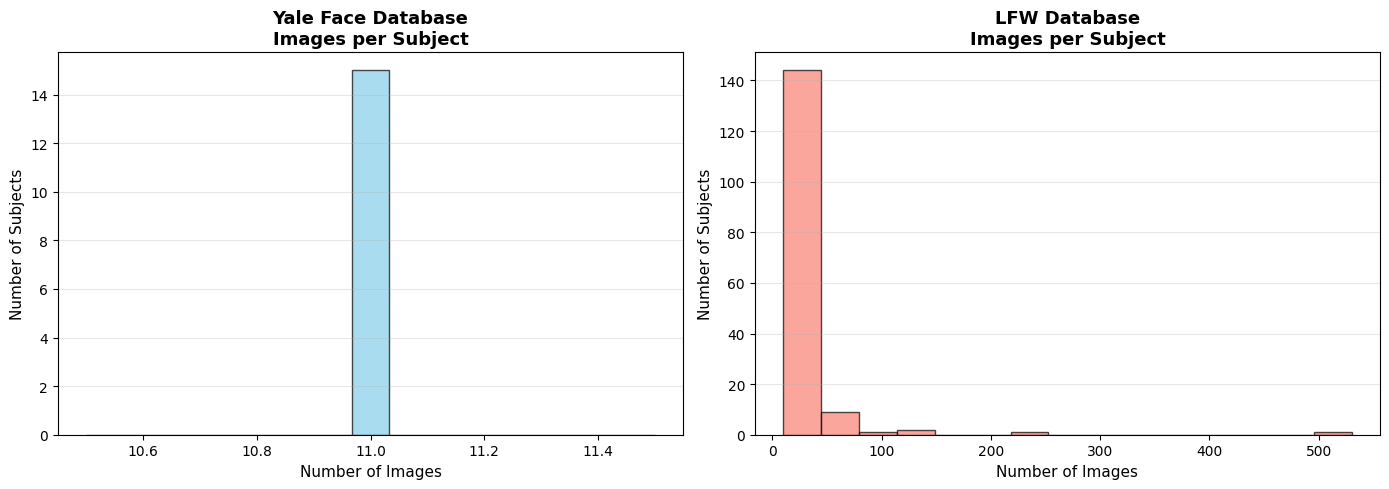


📸 Displaying sample images from both datasets...


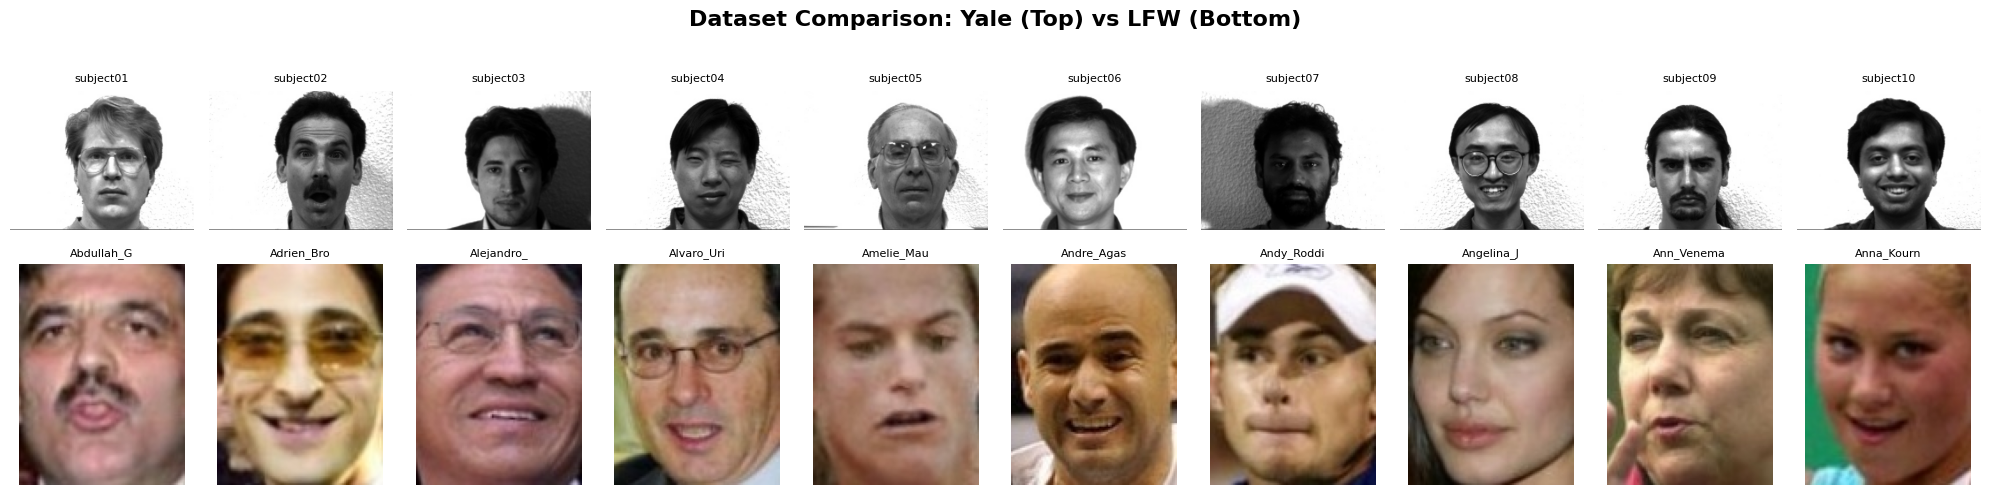


✅ Data exploration complete!


In [ ]:
"""
CELL 5: DATA EXPLORATION AND STATISTICS
Compare both datasets visually
"""

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

print("="*80)
print("📊 DATASET COMPARISON: YALE vs LFW")
print("="*80)

# Analyze Yale dataset
YALE_DIR = 'yale_faces'
yale_subjects = sorted([d for d in os.listdir(YALE_DIR)
                       if os.path.isdir(os.path.join(YALE_DIR, d))])

yale_stats = []
yale_total = 0

for subject in yale_subjects:
    subject_path = os.path.join(YALE_DIR, subject)
    images = [f for f in os.listdir(subject_path) if f.endswith('.jpg')]
    yale_stats.append(len(images))
    yale_total += len(images)

# Analyze LFW dataset
LFW_FILTERED_DIR = 'lfw_filtered'
lfw_subjects = sorted([d for d in os.listdir(LFW_FILTERED_DIR)
                       if os.path.isdir(os.path.join(LFW_FILTERED_DIR, d))])

lfw_stats = []
lfw_total = 0

for subject in lfw_subjects:
    subject_path = os.path.join(LFW_FILTERED_DIR, subject)
    images = [f for f in os.listdir(subject_path) if f.endswith('.jpg')]
    lfw_stats.append(len(images))
    lfw_total += len(images)

# Print statistics
print(f"\n📈 YALE FACE DATABASE (Controlled):")
print(f"   Subjects: {len(yale_subjects)}")
print(f"   Total Images: {yale_total}")
print(f"   Images/Subject: {np.mean(yale_stats):.1f} ± {np.std(yale_stats):.1f}")
print(f"   Min/Max: {np.min(yale_stats)} / {np.max(yale_stats)}")

print(f"\n📈 LFW DATABASE (Uncontrolled):")
print(f"   Subjects: {len(lfw_subjects)}")
print(f"   Total Images: {lfw_total}")
print(f"   Images/Subject: {np.mean(lfw_stats):.1f} ± {np.std(lfw_stats):.1f}")
print(f"   Min/Max: {np.min(lfw_stats)} / {np.max(lfw_stats)}")

# Visualize distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(yale_stats, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Yale Face Database\nImages per Subject', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Images', fontsize=11)
axes[0].set_ylabel('Number of Subjects', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(lfw_stats, bins=15, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('LFW Database\nImages per Subject', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Images', fontsize=11)
axes[1].set_ylabel('Number of Subjects', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Display sample images side by side
print("\n📸 Displaying sample images from both datasets...")

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Dataset Comparison: Yale (Top) vs LFW (Bottom)',
             fontsize=16, fontweight='bold')

# Yale samples (top row)
for i in range(10):
    if i < len(yale_subjects):
        subject = yale_subjects[i]
        subject_path = os.path.join(YALE_DIR, subject)
        images = [f for f in os.listdir(subject_path) if f.endswith('.jpg')]
        if images:
            img = Image.open(os.path.join(subject_path, images[0]))
            axes[0, i].imshow(img)
            axes[0, i].set_title(f'{subject[:10]}', fontsize=8)
            axes[0, i].axis('off')

# LFW samples (bottom row)
for i in range(10):
    if i < len(lfw_subjects):
        subject = lfw_subjects[i]
        subject_path = os.path.join(LFW_FILTERED_DIR, subject)
        images = [f for f in os.listdir(subject_path) if f.endswith('.jpg')]
        if images:
            img = Image.open(os.path.join(subject_path, images[0]))
            axes[1, i].imshow(img)
            axes[1, i].set_title(f'{subject[:10]}', fontsize=8)
            axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Data exploration complete!")
print("="*80)

**Preprocessing Functions**


✅ Preprocessing functions defined!

🧪 Testing preprocessing pipeline...


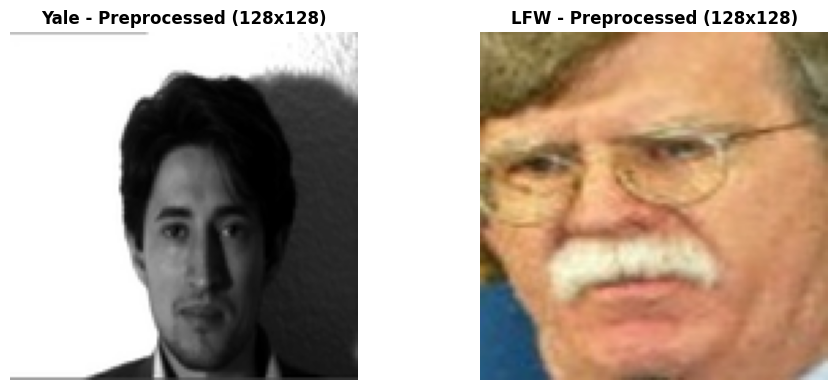

✅ Preprocessing pipeline working correctly!


In [ ]:
"""
CELL 6: PREPROCESSING PIPELINE
Functions for image preprocessing and augmentation
"""

import cv2
import numpy as np
from PIL import Image

class FacePreprocessor:
    def __init__(self, target_size=(128, 128)):
        self.target_size = target_size

    def preprocess_image(self, img_path):
        """Load and preprocess a single image"""
        try:
            # Load image
            img = Image.open(img_path)
            img = img.convert('RGB')

            # Resize to target size
            img = img.resize(self.target_size, Image.LANCZOS)

            # Convert to numpy array
            img_array = np.array(img)

            # Normalize to [0, 1]
            img_array = img_array.astype('float32') / 255.0

            return img_array

        except Exception as e:
            print(f"Error processing {img_path}: {str(e)}")
            return None

    def histogram_equalization(self, image):
        """Apply histogram equalization for better contrast"""
        # Convert to uint8 for processing
        img_uint8 = (image * 255).astype(np.uint8)

        # Convert to YCrCb color space
        img_ycrcb = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YCrCb)

        # Equalize the Y channel
        img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])

        # Convert back to RGB
        img_output = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2RGB)

        # Normalize back to [0, 1]
        return img_output.astype('float32') / 255.0

print("✅ Preprocessing functions defined!")

# Test preprocessing on a sample image
print("\n🧪 Testing preprocessing pipeline...")

# Get a sample image from Yale
yale_sample_subject = os.listdir(YALE_DIR)[0]
yale_sample_path = os.path.join(YALE_DIR, yale_sample_subject)
yale_sample_img = os.listdir(yale_sample_path)[0]
yale_full_path = os.path.join(yale_sample_path, yale_sample_img)

# Get a sample from LFW
lfw_sample_subject = os.listdir(LFW_FILTERED_DIR)[0]
lfw_sample_path = os.path.join(LFW_FILTERED_DIR, lfw_sample_subject)
lfw_sample_img = os.listdir(lfw_sample_path)[0]
lfw_full_path = os.path.join(lfw_sample_path, lfw_sample_img)

# Preprocess
preprocessor = FacePreprocessor()
yale_processed = preprocessor.preprocess_image(yale_full_path)
lfw_processed = preprocessor.preprocess_image(lfw_full_path)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(yale_processed)
axes[0].set_title('Yale - Preprocessed (128x128)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(lfw_processed)
axes[1].set_title('LFW - Preprocessed (128x128)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('preprocessing_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Preprocessing pipeline working correctly!")

**Load and Prepare Both Datasets**

In [ ]:
"""
CELL 7: LOAD AND PREPARE BOTH DATASETS
Load all images and create labels
"""

import numpy as np
from sklearn.preprocessing import LabelEncoder
import time

def load_dataset(dataset_path, dataset_name, max_subjects=15):
    """Load dataset with preprocessing"""
    print(f"\n{'='*70}")
    print(f"📂 LOADING {dataset_name}")
    print(f"{'='*70}")

    start_time = time.time()

    preprocessor = FacePreprocessor(target_size=(128, 128))

    images = []
    labels = []
    label_names = []

    subjects = sorted([d for d in os.listdir(dataset_path)
                      if os.path.isdir(os.path.join(dataset_path, d))])

    # Use first max_subjects for balanced comparison
    if max_subjects and len(subjects) > max_subjects:
        subjects = subjects[:max_subjects]
        print(f"📊 Using first {max_subjects} subjects for balanced comparison")

    for label_idx, subject in enumerate(subjects):
        subject_path = os.path.join(dataset_path, subject)
        img_files = [f for f in os.listdir(subject_path) if f.endswith('.jpg')]

        subject_images = 0
        for img_file in img_files:
            img_path = os.path.join(subject_path, img_file)
            img = preprocessor.preprocess_image(img_path)

            if img is not None:
                images.append(img)
                labels.append(label_idx)
                subject_images += 1

        label_names.append(subject)
        print(f"   [{label_idx+1:2d}/{len(subjects):2d}] {subject[:30]:30} : {subject_images:3d} images")

    images = np.array(images)
    labels = np.array(labels)

    elapsed = time.time() - start_time

    print(f"\n✅ {dataset_name} loaded successfully!")
    print(f"   Shape: {images.shape}")
    print(f"   Labels: {labels.shape}")
    print(f"   Classes: {len(label_names)}")
    print(f"   Time: {elapsed:.2f} seconds")
    print(f"{'='*70}")

    return images, labels, label_names

# Load Yale Face Database (Controlled Environment)
X_yale, y_yale, yale_names = load_dataset(
    YALE_DIR,
    "YALE FACE DATABASE (Controlled)",
    max_subjects=15
)

# Load LFW Database (Uncontrolled Environment)
X_lfw, y_lfw, lfw_names = load_dataset(
    LFW_FILTERED_DIR,
    "LFW DATABASE (Uncontrolled)",
    max_subjects=15
)

# Save preprocessed datasets
print("\n💾 Saving preprocessed datasets...")
np.savez_compressed('yale_preprocessed.npz',
                    X=X_yale, y=y_yale, names=yale_names)
np.savez_compressed('lfw_preprocessed.npz',
                    X=X_lfw, y=y_lfw, names=lfw_names)
print("✅ Datasets saved!")

# Summary
print("\n" + "="*70)
print("📊 DATASET LOADING SUMMARY")
print("="*70)
print(f"\nYale Dataset:")
print(f"   Images: {len(X_yale)}")
print(f"   Subjects: {len(yale_names)}")
print(f"   Shape: {X_yale.shape}")

print(f"\nLFW Dataset:")
print(f"   Images: {len(X_lfw)}")
print(f"   Subjects: {len(lfw_names)}")
print(f"   Shape: {X_lfw.shape}")

print("\n✅ Both datasets ready for model training!")
print("="*70)


📂 LOADING YALE FACE DATABASE (Controlled)
   [ 1/15] subject01                      :  11 images
   [ 2/15] subject02                      :  11 images
   [ 3/15] subject03                      :  11 images
   [ 4/15] subject04                      :  11 images
   [ 5/15] subject05                      :  11 images
   [ 6/15] subject06                      :  11 images
   [ 7/15] subject07                      :  11 images
   [ 8/15] subject08                      :  11 images
   [ 9/15] subject09                      :  11 images
   [10/15] subject10                      :  11 images
   [11/15] subject11                      :  11 images
   [12/15] subject12                      :  11 images
   [13/15] subject13                      :  11 images
   [14/15] subject14                      :  11 images
   [15/15] subject15                      :  11 images

✅ YALE FACE DATABASE (Controlled) loaded successfully!
   Shape: (165, 128, 128, 3)
   Labels: (165,)
   Classes: 15
   Time: 0.55 

**Train-Test Split**

In [ ]:
"""
CELL 8: TRAIN-TEST SPLIT
Split both datasets into training and testing sets
"""

from sklearn.model_selection import train_test_split

print("="*70)
print("🔀 CREATING TRAIN-TEST SPLITS")
print("="*70)

# Yale dataset split (80% train, 20% test)
X_yale_train, X_yale_test, y_yale_train, y_yale_test = train_test_split(
    X_yale, y_yale,
    test_size=0.2,
    random_state=42,
    stratify=y_yale
)

print(f"\n📊 Yale Dataset Split:")
print(f"   Training set: {X_yale_train.shape[0]} images")
print(f"   Testing set:  {X_yale_test.shape[0]} images")
print(f"   Split ratio: 80/20")

# LFW dataset split (80% train, 20% test)
X_lfw_train, X_lfw_test, y_lfw_train, y_lfw_test = train_test_split(
    X_lfw, y_lfw,
    test_size=0.2,
    random_state=42,
    stratify=y_lfw
)

print(f"\n📊 LFW Dataset Split:")
print(f"   Training set: {X_lfw_train.shape[0]} images")
print(f"   Testing set:  {X_lfw_test.shape[0]} images")
print(f"   Split ratio: 80/20")

# Verify class distribution
print(f"\n✓ Stratified split ensures balanced class distribution")
print(f"✓ Same random_state (42) for reproducibility")

print("\n✅ Train-test splits ready!")
print("="*70)

🔀 CREATING TRAIN-TEST SPLITS

📊 Yale Dataset Split:
   Training set: 132 images
   Testing set:  33 images
   Split ratio: 80/20

📊 LFW Dataset Split:
   Training set: 324 images
   Testing set:  81 images
   Split ratio: 80/20

✓ Stratified split ensures balanced class distribution
✓ Same random_state (42) for reproducibility

✅ Train-test splits ready!


**Model 1 - HOG + SVM**

In [ ]:
"""
CELL 9: MODEL 1 - HOG FEATURES + SVM CLASSIFIER
Traditional computer vision approach
"""

from sklearn.svm import SVC
from skimage.feature import hog
import time

class HOG_SVM_Model:
    def __init__(self, C=10, gamma='scale'):
        self.svm = SVC(kernel='rbf', C=C, gamma=gamma, probability=True)
        self.name = "HOG + SVM"

    def extract_hog_features(self, images):
        """Extract HOG features from images"""
        print(f"   Extracting HOG features from {len(images)} images...")
        features = []

        for idx, img in enumerate(images):
            # Convert to grayscale
            if len(img.shape) == 3:
                img_gray = cv2.cvtColor((img * 255).astype(np.uint8),
                                       cv2.COLOR_RGB2GRAY)
            else:
                img_gray = (img * 255).astype(np.uint8)

            # Extract HOG features
            fd = hog(img_gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=False,
                    feature_vector=True)
            features.append(fd)

            if (idx + 1) % 50 == 0:
                print(f"      Processed {idx + 1}/{len(images)} images...", end='\r')

        print(f"      Processed {len(images)}/{len(images)} images... Done!")
        return np.array(features)

    def train(self, X_train, y_train):
        """Train SVM on HOG features"""
        print(f"\n🔧 Training {self.name}...")
        start_time = time.time()

        X_features = self.extract_hog_features(X_train)
        print(f"   Feature shape: {X_features.shape}")

        print(f"   Training SVM classifier...")
        self.svm.fit(X_features, y_train)

        elapsed = time.time() - start_time
        print(f"✅ {self.name} trained in {elapsed:.2f} seconds!")

    def predict(self, X_test):
        """Predict using trained model"""
        X_features = self.extract_hog_features(X_test)
        return self.svm.predict(X_features)

    def predict_proba(self, X_test):
        """Get prediction probabilities"""
        X_features = self.extract_hog_features(X_test)
        return self.svm.predict_proba(X_features)

print("✅ HOG + SVM Model class defined!")

✅ HOG + SVM Model class defined!


**Model 2 - PCA + Random Forest**

In [ ]:
"""
CELL 10: MODEL 2 - PCA + RANDOM FOREST
Dimensionality reduction + Ensemble learning
"""

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

class PCA_RF_Model:
    def __init__(self, n_components=100, n_estimators=200):
        self.pca = PCA(n_components=n_components, whiten=True, random_state=42)
        self.rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        self.name = "PCA + Random Forest"

    def preprocess(self, images):
        """Flatten images for PCA"""
        return images.reshape(len(images), -1)

    def train(self, X_train, y_train):
        """Train PCA + Random Forest"""
        print(f"\n🔧 Training {self.name}...")
        start_time = time.time()

        # Flatten images
        print(f"   Flattening images...")
        X_flat = self.preprocess(X_train)
        print(f"   Flattened shape: {X_flat.shape}")

        # Apply PCA
        print(f"   Applying PCA (n_components={self.pca.n_components})...")
        X_pca = self.pca.fit_transform(X_flat)
        print(f"   PCA shape: {X_pca.shape}")
        print(f"   Explained variance: {sum(self.pca.explained_variance_ratio_):.4f}")

        # Train Random Forest
        print(f"   Training Random Forest...")
        self.rf.fit(X_pca, y_train)

        elapsed = time.time() - start_time
        print(f"✅ {self.name} trained in {elapsed:.2f} seconds!")

    def predict(self, X_test):
        """Predict using PCA + RF"""
        X_flat = self.preprocess(X_test)
        X_pca = self.pca.transform(X_flat)
        return self.rf.predict(X_pca)

    def predict_proba(self, X_test):
        """Get prediction probabilities"""
        X_flat = self.preprocess(X_test)
        X_pca = self.pca.transform(X_flat)
        return self.rf.predict_proba(X_pca)

print("✅ PCA + Random Forest Model class defined!")

✅ PCA + Random Forest Model class defined!


**Model 3 - Custom CNN**

In [ ]:
"""
CELL 11: MODEL 3 - CUSTOM CNN
Deep learning approach with custom architecture
"""

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

class CustomCNN:
    def __init__(self, num_classes, input_shape=(128, 128, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.name = "Custom CNN"
        self.model = self.build_model()
        self.history = None

    def build_model(self):
        """Build CNN architecture"""
        model = models.Sequential([
            # Block 1
            layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                         input_shape=self.input_shape),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Block 2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Block 3
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Block 4
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Dense layers
            layers.Flatten(),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def train(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
        """Train CNN"""
        print(f"\n🔧 Training {self.name}...")
        print(f"   Architecture: {len(self.model.layers)} layers")
        print(f"   Parameters: {self.model.count_params():,}")

        # Data augmentation
        datagen = tf.keras.preprocessing.image.ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            horizontal_flip=True,
            zoom_range=0.15,
            fill_mode='nearest'
        )

        # Callbacks
        cb = [
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=15,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=7,
                min_lr=1e-7,
                verbose=1
            )
        ]

        print(f"   Training with data augmentation...")
        start_time = time.time()

        self.history = self.model.fit(
            datagen.flow(X_train, y_train, batch_size=batch_size),
            validation_data=(X_val, y_val),
            epochs=epochs,
            callbacks=cb,
            verbose=1
        )

        elapsed = time.time() - start_time
        print(f"\n✅ {self.name} trained in {elapsed:.2f} seconds!")

        return self.history

    def predict(self, X_test):
        """Predict labels"""
        predictions = self.model.predict(X_test, verbose=0)
        return np.argmax(predictions, axis=1)

    def predict_proba(self, X_test):
        """Get prediction probabilities"""
        return self.model.predict(X_test, verbose=0)

    def plot_history(self, dataset_name):
        """Plot training history"""
        if self.history is None:
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Accuracy
        axes[0].plot(self.history.history['accuracy'], label='Train', linewidth=2)
        axes[0].plot(self.history.history['val_accuracy'], label='Validation', linewidth=2)
        axes[0].set_title(f'{self.name} - {dataset_name}\nAccuracy',
                         fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Epoch', fontsize=11)
        axes[0].set_ylabel('Accuracy', fontsize=11)
        axes[0].legend(fontsize=10)
        axes[0].grid(True, alpha=0.3)

        # Loss
        axes[1].plot(self.history.history['loss'], label='Train', linewidth=2)
        axes[1].plot(self.history.history['val_loss'], label='Validation', linewidth=2)
        axes[1].set_title(f'{self.name} - {dataset_name}\nLoss',
                         fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Epoch', fontsize=11)
        axes[1].set_ylabel('Loss', fontsize=11)
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'cnn_history_{dataset_name}.png', dpi=300, bbox_inches='tight')
        plt.show()

print("✅ Custom CNN Model class defined!")

✅ Custom CNN Model class defined!


**Model 4 - VGG16 Transfer Learning**

In [ ]:
"""
CELL 12: MODEL 4 - VGG16 TRANSFER LEARNING
Pre-trained deep learning model
"""

from tensorflow.keras.applications import VGG16

class VGG16_TransferLearning:
    def __init__(self, num_classes, input_shape=(128, 128, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.name = "VGG16 Transfer Learning"
        self.model = self.build_model()
        self.history = None

    def build_model(self):
        """Build transfer learning model"""
        # Load VGG16 without top layers
        base_model = VGG16(
            weights='imagenet',
            include_top=False,
            input_shape=self.input_shape
        )

        # Freeze early layers (fine-tune last 4 layers)
        for layer in base_model.layers[:-4]:
            layer.trainable = False

        # Build complete model
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def train(self, X_train, y_train, X_val, y_val, epochs=30, batch_size=16):
        """Train model"""
        print(f"\n🔧 Training {self.name}...")
        print(f"   Using pre-trained ImageNet weights")
        print(f"   Parameters: {self.model.count_params():,}")

        # Data augmentation
        datagen = tf.keras.preprocessing.image.ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            horizontal_flip=True,
            zoom_range=0.1
        )

        # Callbacks
        cb = [
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            )
        ]

        print(f"   Training with transfer learning...")
        start_time = time.time()

        self.history = self.model.fit(
            datagen.flow(X_train, y_train, batch_size=batch_size),
            validation_data=(X_val, y_val),
            epochs=epochs,
            callbacks=cb,
            verbose=1
        )

        elapsed = time.time() - start_time
        print(f"\n✅ {self.name} trained in {elapsed:.2f} seconds!")

        return self.history

    def predict(self, X_test):
        """Predict labels"""
        predictions = self.model.predict(X_test, verbose=0)
        return np.argmax(predictions, axis=1)

    def predict_proba(self, X_test):
        """Get prediction probabilities"""
        return self.model.predict(X_test, verbose=0)

    def plot_history(self, dataset_name):
        """Plot training history"""
        if self.history is None:
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(self.history.history['accuracy'], label='Train', linewidth=2)
        axes[0].plot(self.history.history['val_accuracy'], label='Validation', linewidth=2)
        axes[0].set_title(f'{self.name} - {dataset_name}\nAccuracy',
                         fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Epoch', fontsize=11)
        axes[0].set_ylabel('Accuracy', fontsize=11)
        axes[0].legend(fontsize=10)
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.history.history['loss'], label='Train', linewidth=2)
        axes[1].plot(self.history.history['val_loss'], label='Validation', linewidth=2)
        axes[1].set_title(f'{self.name} - {dataset_name}\nLoss',
                         fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Epoch', fontsize=11)
        axes[1].set_ylabel('Loss', fontsize=11)
        axes[1].legend(fontsize=10)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'vgg16_history_{dataset_name}.png', dpi=300, bbox_inches='tight')
        plt.show()

print("✅ VGG16 Transfer Learning Model class defined!")

✅ VGG16 Transfer Learning Model class defined!


**Evaluation Framework**

In [ ]:
"""
CELL 13: EVALUATION FRAMEWORK
Comprehensive model evaluation metrics
"""

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import seaborn as sns

class ModelEvaluator:
    def __init__(self):
        self.results = {}

    def evaluate(self, model_name, y_true, y_pred):
        """Comprehensive model evaluation"""
        results = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'f1_score': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'confusion_matrix': confusion_matrix(y_true, y_pred),
            'y_true': y_true,
            'y_pred': y_pred
        }

        self.results[model_name] = results

        print(f"\n📊 {model_name} - Evaluation Results:")
        print(f"   Accuracy:  {results['accuracy']:.4f}")
        print(f"   Precision: {results['precision']:.4f}")
        print(f"   Recall:    {results['recall']:.4f}")
        print(f"   F1-Score:  {results['f1_score']:.4f}")

        return results

    def plot_confusion_matrix(self, model_name, class_names=None, figsize=(10, 8)):
        """Plot confusion matrix heatmap"""
        if model_name not in self.results:
            print(f"No results for {model_name}")
            return

        cm = self.results[model_name]['confusion_matrix']

        plt.figure(figsize=figsize)

        if class_names and len(class_names) <= 20:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=class_names, yticklabels=class_names,
                       cbar_kws={'label': 'Count'})
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.yticks(rotation=0, fontsize=8)
        else:
            sns.heatmap(cm, cmap='Blues', cbar_kws={'label': 'Count'})

        plt.title(f'Confusion Matrix - {model_name}',
                 fontsize=14, fontweight='bold', pad=20)
        plt.ylabel('True Label', fontsize=12, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
        plt.tight_layout()

        safe_name = model_name.replace(' ', '_').replace('+', 'plus')
        plt.savefig(f'confusion_matrix_{safe_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

    def get_summary_dataframe(self):
        """Get summary DataFrame of all results"""
        import pandas as pd

        summary = []
        for model_name, results in self.results.items():
            summary.append({
                'Model': model_name,
                'Accuracy': results['accuracy'],
                'Precision': results['precision'],
                'Recall': results['recall'],
                'F1-Score': results['f1_score']
            })

        return pd.DataFrame(summary)

# Create global evaluator
evaluator = ModelEvaluator()

print("✅ Evaluation framework ready!")

✅ Evaluation framework ready!


**Train All Models on Yale Dataset (Controlled)**


🎯 TRAINING ALL MODELS ON YALE FACE DATABASE (CONTROLLED ENVIRONMENT)

--------------------------------------------------------------------------------
MODEL 1/4: HOG + SVM
--------------------------------------------------------------------------------

🔧 Training HOG + SVM...
   Extracting HOG features from 132 images...
      Processed 132/132 images... Done!
   Feature shape: (132, 8100)
   Training SVM classifier...
✅ HOG + SVM trained in 1.06 seconds!
   Extracting HOG features from 33 images...
      Processed 33/33 images... Done!

📊 HOG+SVM (Yale) - Evaluation Results:
   Accuracy:  0.9394
   Precision: 0.9596
   Recall:    0.9394
   F1-Score:  0.9374

--------------------------------------------------------------------------------
MODEL 2/4: PCA + Random Forest
--------------------------------------------------------------------------------

🔧 Training PCA + Random Forest...
   Flattening images...
   Flattened shape: (132, 49152)
   Applying PCA (n_components=100)...
   PCA 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,112,367 (34.76 MB)

 Trainable params: 9,109,423 (34.75 MB)

 Non-trainable params: 2,944 (11.50 KB)


🔧 Training Custom CNN...
   Architecture: 30 layers
   Parameters: 9,112,367
   Training with data augmentation...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.0708 - loss: 4.3010 - val_accuracy: 0.0606 - val_loss: 2.7362 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.0855 - loss: 3.9835 - val_accuracy: 0.0606 - val_loss: 2.8916 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.1123 - loss: 3.8114 - val_accuracy: 0.0606 - val_loss: 3.1613 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.0953 - loss: 3.6165 - val_accuracy: 0.0606 - val_loss: 3.3946 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.1922 - loss: 3.0157 - val_accuracy: 0.0606 - val_loss: 3.6366 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.1538 - loss: 3.2452 - val_accuracy: 0.0606 - val_loss: 3.8272 - learning_rate: 0.0

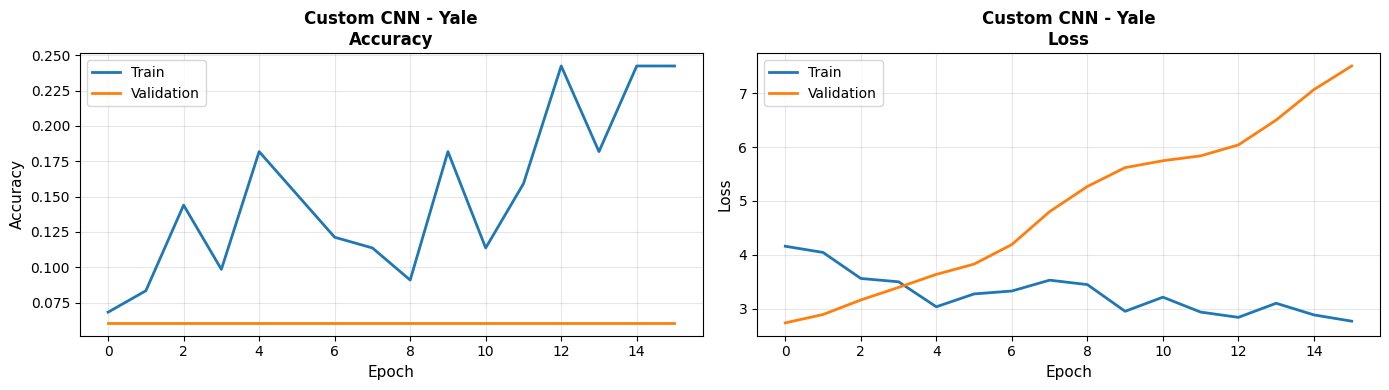


--------------------------------------------------------------------------------
MODEL 4/4: VGG16 Transfer Learning
--------------------------------------------------------------------------------
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📋 Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,115,599 (57.66 MB)

 Trainable params: 7,478,799 (28.53 MB)

 Non-trainable params: 7,636,800 (29.13 MB)


🔧 Training VGG16 Transfer Learning...
   Using pre-trained ImageNet weights
   Parameters: 15,115,599
   Training with transfer learning...
Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.0427 - loss: 4.2447 - val_accuracy: 0.0303 - val_loss: 2.7352 - learning_rate: 1.0000e-04
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.1336 - loss: 3.4059 - val_accuracy: 0.0909 - val_loss: 2.6824 - learning_rate: 1.0000e-04
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.2075 - loss: 2.9937 - val_accuracy: 0.1515 - val_loss: 2.6255 - learning_rate: 1.0000e-04
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.2125 - loss: 2.5878 - val_accuracy: 0.1212 - val_loss: 2.5870 - learning_rate: 1.0000e-04
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.3253 - loss: 2.3667 - val_accuracy: 0.2424 - val_loss: 2.5238 - learning_rate: 1.0000e-04
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.3482 - loss: 2.2472 - val_accuracy: 0

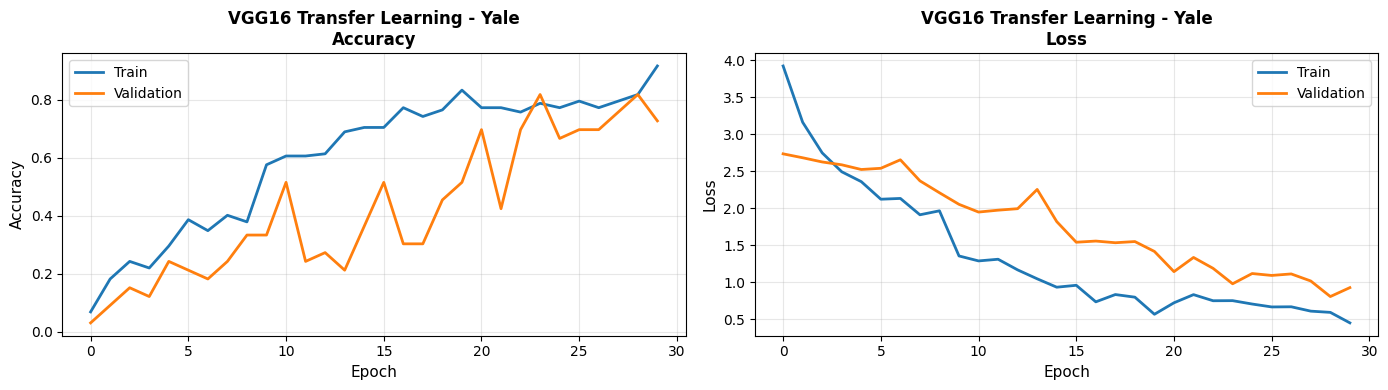


✅ ALL MODELS TRAINED ON YALE DATASET!


In [ ]:
"""
CELL 14: TRAIN ALL MODELS ON YALE DATASET (CONTROLLED ENVIRONMENT)
"""

print("\n" + "="*80)
print("🎯 TRAINING ALL MODELS ON YALE FACE DATABASE (CONTROLLED ENVIRONMENT)")
print("="*80)

num_classes_yale = len(np.unique(y_yale))

# ============================================================================
# MODEL 1: HOG + SVM
# ============================================================================
print("\n" + "-"*80)
print("MODEL 1/4: HOG + SVM")
print("-"*80)

hog_svm_yale = HOG_SVM_Model(C=10, gamma='scale')
hog_svm_yale.train(X_yale_train, y_yale_train)

y_pred_hog_yale = hog_svm_yale.predict(X_yale_test)
evaluator.evaluate("HOG+SVM (Yale)", y_yale_test, y_pred_hog_yale)

# ============================================================================
# MODEL 2: PCA + Random Forest
# ============================================================================
print("\n" + "-"*80)
print("MODEL 2/4: PCA + Random Forest")
print("-"*80)

pca_rf_yale = PCA_RF_Model(n_components=100, n_estimators=200)
pca_rf_yale.train(X_yale_train, y_yale_train)

y_pred_pca_yale = pca_rf_yale.predict(X_yale_test)
evaluator.evaluate("PCA+RF (Yale)", y_yale_test, y_pred_pca_yale)

# ============================================================================
# MODEL 3: Custom CNN
# ============================================================================
print("\n" + "-"*80)
print("MODEL 3/4: Custom CNN")
print("-"*80)

cnn_yale = CustomCNN(num_classes=num_classes_yale)
print("\n📋 Model Architecture:")
cnn_yale.model.summary()

cnn_yale.train(X_yale_train, y_yale_train, X_yale_test, y_yale_test, epochs=50, batch_size=32)

y_pred_cnn_yale = cnn_yale.predict(X_yale_test)
evaluator.evaluate("Custom CNN (Yale)", y_yale_test, y_pred_cnn_yale)

# Plot training history
cnn_yale.plot_history("Yale")

# ============================================================================
# MODEL 4: VGG16 Transfer Learning
# ============================================================================
print("\n" + "-"*80)
print("MODEL 4/4: VGG16 Transfer Learning")
print("-"*80)

vgg_yale = VGG16_TransferLearning(num_classes=num_classes_yale)
print("\n📋 Model Architecture:")
vgg_yale.model.summary()

vgg_yale.train(X_yale_train, y_yale_train, X_yale_test, y_yale_test, epochs=30, batch_size=16)

y_pred_vgg_yale = vgg_yale.predict(X_yale_test)
evaluator.evaluate("VGG16 (Yale)", y_yale_test, y_pred_vgg_yale)

# Plot training history
vgg_yale.plot_history("Yale")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED ON YALE DATASET!")
print("="*80)

**Train All Models on LFW Dataset (Uncontrolled)**


🎯 TRAINING ALL MODELS ON LFW DATABASE (UNCONTROLLED ENVIRONMENT)

--------------------------------------------------------------------------------
MODEL 1/4: HOG + SVM
--------------------------------------------------------------------------------

🔧 Training HOG + SVM...
   Extracting HOG features from 324 images...
      Processed 324/324 images... Done!
   Feature shape: (324, 8100)
   Training SVM classifier...
✅ HOG + SVM trained in 3.95 seconds!
   Extracting HOG features from 81 images...
      Processed 81/81 images... Done!

📊 HOG+SVM (LFW) - Evaluation Results:
   Accuracy:  0.6790
   Precision: 0.6638
   Recall:    0.6790
   F1-Score:  0.6355

--------------------------------------------------------------------------------
MODEL 2/4: PCA + Random Forest
--------------------------------------------------------------------------------

🔧 Training PCA + Random Forest...
   Flattening images...
   Flattened shape: (324, 49152)
   Applying PCA (n_components=100)...
   PCA shape


📊 Custom CNN (LFW) - Evaluation Results:
   Accuracy:  0.0988
   Precision: 0.0240
   Recall:    0.0988
   F1-Score:  0.0334


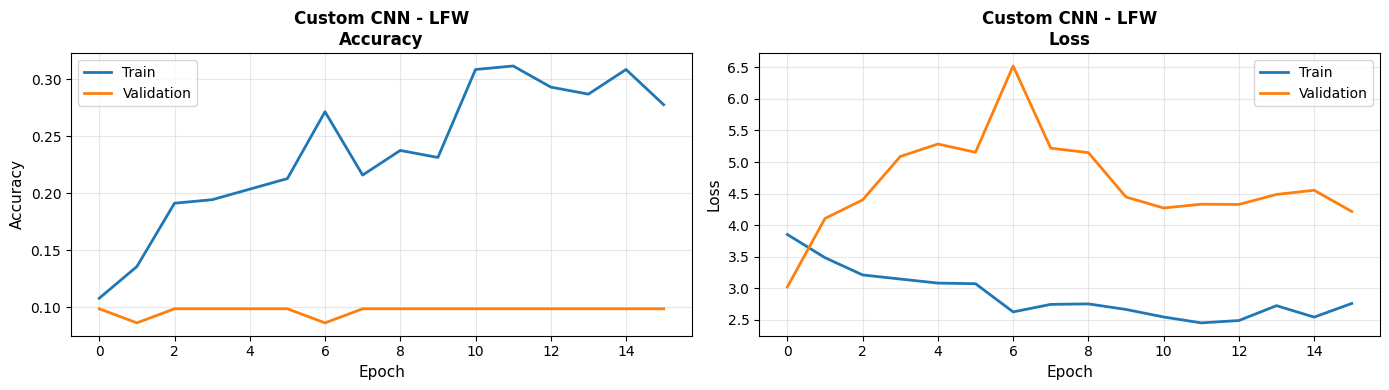


--------------------------------------------------------------------------------
MODEL 4/4: VGG16 Transfer Learning
--------------------------------------------------------------------------------

🔧 Training VGG16 Transfer Learning...
   Using pre-trained ImageNet weights
   Parameters: 15,115,599
   Training with transfer learning...
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.1279 - loss: 3.8168 - val_accuracy: 0.1358 - val_loss: 2.6092 - learning_rate: 1.0000e-04
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.2481 - loss: 2.9193 - val_accuracy: 0.0988 - val_loss: 2.5720 - learning_rate: 1.0000e-04
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2341 - loss: 2.7998 - val_accuracy: 0.1975 - val_loss: 2.5024 - learning_rate: 1.0000e-04
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2976 - loss: 2.5718 - val_accuracy: 0.3580 - val_loss: 2.3596 - learning_rate: 1.0000e-04
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/

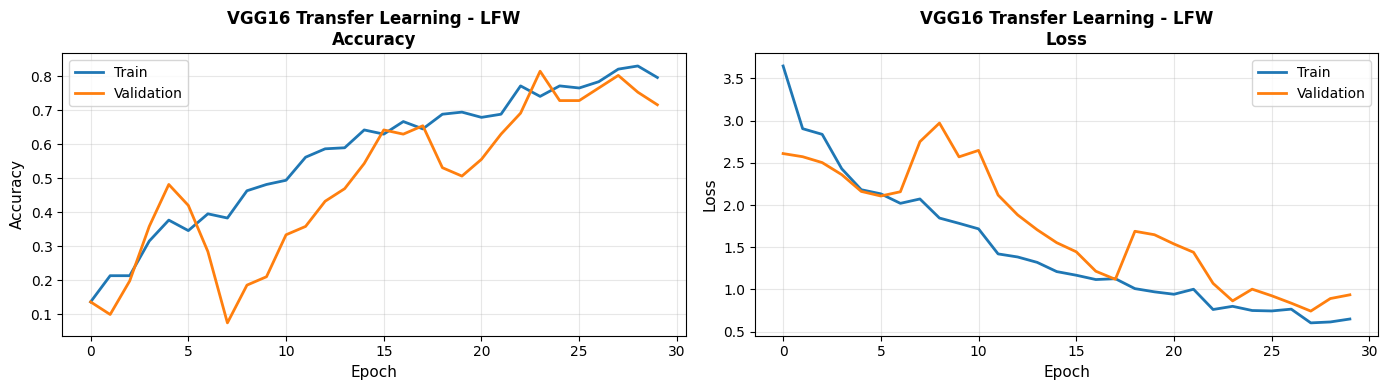


✅ ALL MODELS TRAINED ON LFW DATASET!


In [ ]:
"""
CELL 15: TRAIN ALL MODELS ON LFW DATASET (UNCONTROLLED ENVIRONMENT)
"""

print("\n" + "="*80)
print("🎯 TRAINING ALL MODELS ON LFW DATABASE (UNCONTROLLED ENVIRONMENT)")
print("="*80)

num_classes_lfw = len(np.unique(y_lfw))

# ============================================================================
# MODEL 1: HOG + SVM
# ============================================================================
print("\n" + "-"*80)
print("MODEL 1/4: HOG + SVM")
print("-"*80)

hog_svm_lfw = HOG_SVM_Model(C=10, gamma='scale')
hog_svm_lfw.train(X_lfw_train, y_lfw_train)

y_pred_hog_lfw = hog_svm_lfw.predict(X_lfw_test)
evaluator.evaluate("HOG+SVM (LFW)", y_lfw_test, y_pred_hog_lfw)

# ============================================================================
# MODEL 2: PCA + Random Forest
# ============================================================================
print("\n" + "-"*80)
print("MODEL 2/4: PCA + Random Forest")
print("-"*80)

pca_rf_lfw = PCA_RF_Model(n_components=100, n_estimators=200)
pca_rf_lfw.train(X_lfw_train, y_lfw_train)

y_pred_pca_lfw = pca_rf_lfw.predict(X_lfw_test)
evaluator.evaluate("PCA+RF (LFW)", y_lfw_test, y_pred_pca_lfw)

# ============================================================================
# MODEL 3: Custom CNN
# ============================================================================
print("\n" + "-"*80)
print("MODEL 3/4: Custom CNN")
print("-"*80)

cnn_lfw = CustomCNN(num_classes=num_classes_lfw)
cnn_lfw.train(X_lfw_train, y_lfw_train, X_lfw_test, y_lfw_test, epochs=50, batch_size=32)

y_pred_cnn_lfw = cnn_lfw.predict(X_lfw_test)
evaluator.evaluate("Custom CNN (LFW)", y_lfw_test, y_pred_cnn_lfw)

# Plot training history
cnn_lfw.plot_history("LFW")

# ============================================================================
# MODEL 4: VGG16 Transfer Learning
# ============================================================================
print("\n" + "-"*80)
print("MODEL 4/4: VGG16 Transfer Learning")
print("-"*80)

vgg_lfw = VGG16_TransferLearning(num_classes=num_classes_lfw)
vgg_lfw.train(X_lfw_train, y_lfw_train, X_lfw_test, y_lfw_test, epochs=30, batch_size=16)

y_pred_vgg_lfw = vgg_lfw.predict(X_lfw_test)
evaluator.evaluate("VGG16 (LFW)", y_lfw_test, y_pred_vgg_lfw)

# Plot training history
vgg_lfw.plot_history("LFW")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED ON LFW DATASET!")
print("="*80)

**Results Summary**

In [ ]:
"""
CELL 16: COMPREHENSIVE RESULTS SUMMARY
"""

import pandas as pd

print("\n" + "="*80)
print("📊 COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

# Get results DataFrame
results_df = evaluator.get_summary_dataframe()

# Add environment column
results_df['Environment'] = results_df['Model'].apply(
    lambda x: 'Controlled' if 'Yale' in x else 'Uncontrolled'
)

# Add model type column
results_df['Model_Type'] = results_df['Model'].apply(
    lambda x: x.split('(')[0].strip()
)

# Reorder columns
results_df = results_df[['Model', 'Environment', 'Model_Type',
                         'Accuracy', 'Precision', 'Recall', 'F1-Score']]

# Display results
print("\n" + "-"*80)
print("DETAILED RESULTS")
print("-"*80)
print(results_df.to_string(index=False))
print("-"*80)

# Summary statistics
print("\n📈 Summary Statistics:")
print("\nBest Performance by Environment:")
print("-"*80)

# Best in controlled environment
best_controlled = results_df[results_df['Environment'] == 'Controlled'].nlargest(1, 'Accuracy')
print(f"\nControlled Environment:")
print(f"   Best Model: {best_controlled['Model'].values[0]}")
print(f"   Accuracy: {best_controlled['Accuracy'].values[0]:.4f}")

# Best in uncontrolled environment
best_uncontrolled = results_df[results_df['Environment'] == 'Uncontrolled'].nlargest(1, 'Accuracy')
print(f"\nUncontrolled Environment:")
print(f"   Best Model: {best_uncontrolled['Model'].values[0]}")
print(f"   Accuracy: {best_uncontrolled['Accuracy'].values[0]:.4f}")

# Save results
results_df.to_csv('comprehensive_results.csv', index=False)
print("\n💾 Results saved to 'comprehensive_results.csv'")

print("\n" + "="*80)


📊 COMPREHENSIVE RESULTS SUMMARY

--------------------------------------------------------------------------------
DETAILED RESULTS
--------------------------------------------------------------------------------
            Model  Environment Model_Type  Accuracy  Precision   Recall  F1-Score
   HOG+SVM (Yale)   Controlled    HOG+SVM  0.939394   0.959596 0.939394  0.937374
    PCA+RF (Yale)   Controlled     PCA+RF  0.909091   0.936869 0.909091  0.904185
Custom CNN (Yale)   Controlled Custom CNN  0.060606   0.003673 0.060606  0.006926
     VGG16 (Yale)   Controlled      VGG16  0.818182   0.761616 0.818182  0.769986
    HOG+SVM (LFW) Uncontrolled    HOG+SVM  0.679012   0.663833 0.679012  0.635504
     PCA+RF (LFW) Uncontrolled     PCA+RF  0.432099   0.454904 0.432099  0.360453
 Custom CNN (LFW) Uncontrolled Custom CNN  0.098765   0.023976 0.098765  0.033398
      VGG16 (LFW) Uncontrolled      VGG16  0.802469   0.836557 0.802469  0.797880
-------------------------------------------------

**Performance Comparison Visualization**


📊 Generating performance comparison visualizations...


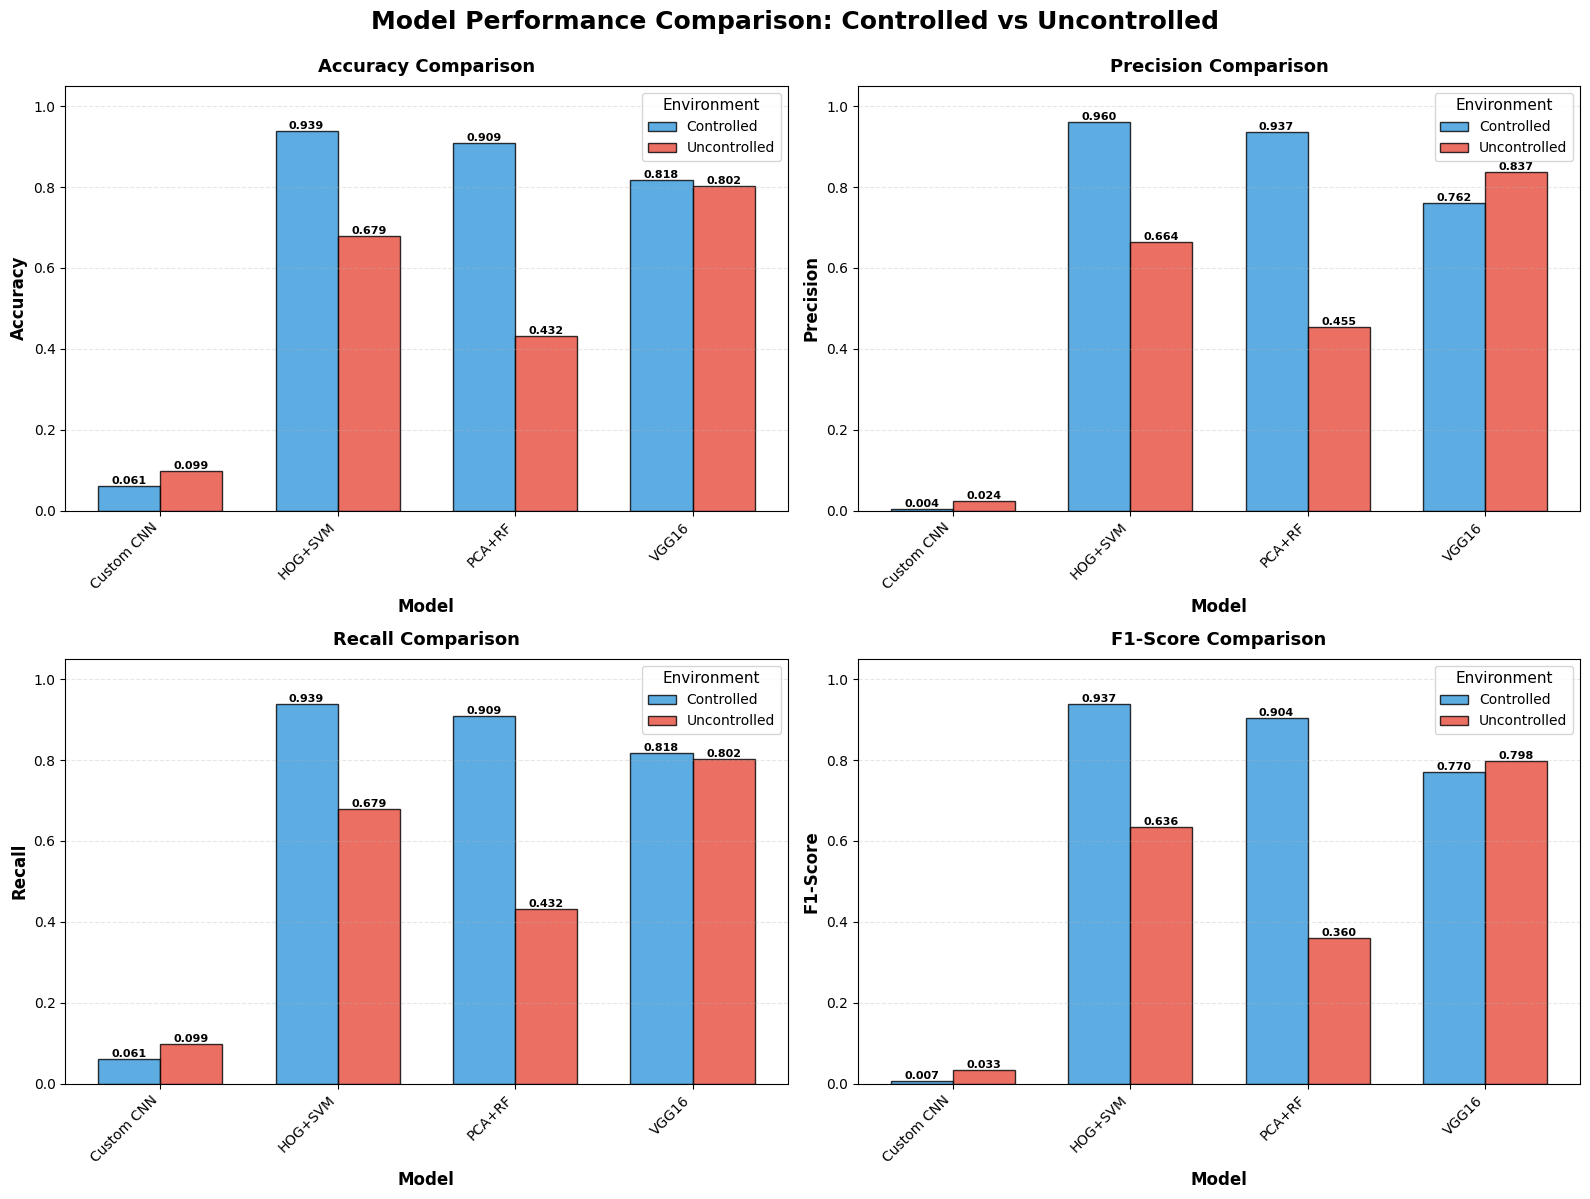

✅ Performance comparison visualization saved!


In [ ]:
"""
CELL 17: PERFORMANCE COMPARISON VISUALIZATION
"""

print("\n📊 Generating performance comparison visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison: Controlled vs Uncontrolled',
             fontsize=18, fontweight='bold', y=0.995)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    # Prepare data for plotting
    pivot_df = results_df.pivot_table(
        values=metric,
        index='Model_Type',
        columns='Environment'
    )

    # Create bar plot
    x = np.arange(len(pivot_df.index))
    width = 0.35

    bars1 = ax.bar(x - width/2, pivot_df['Controlled'], width,
                   label='Controlled', color=colors[0], alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, pivot_df['Uncontrolled'], width,
                   label='Uncontrolled', color=colors[1], alpha=0.8, edgecolor='black')

    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=45, ha='right', fontsize=10)
    ax.legend(title='Environment', fontsize=10, title_fontsize=11)
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Performance comparison visualization saved!")

 **Performance Degradation Analysis**


📉 PERFORMANCE DEGRADATION ANALYSIS

--------------------------------------------------------------------------------
PERFORMANCE DEGRADATION TABLE
--------------------------------------------------------------------------------
     Model  Controlled_Accuracy  Uncontrolled_Accuracy  Performance_Drop  Drop_Percentage
   HOG+SVM             0.939394               0.679012          0.260382        27.718041
    PCA+RF             0.909091               0.432099          0.476992        52.469136
Custom CNN             0.060606               0.098765         -0.038159       -62.962963
     VGG16             0.818182               0.802469          0.015713         1.920439
--------------------------------------------------------------------------------


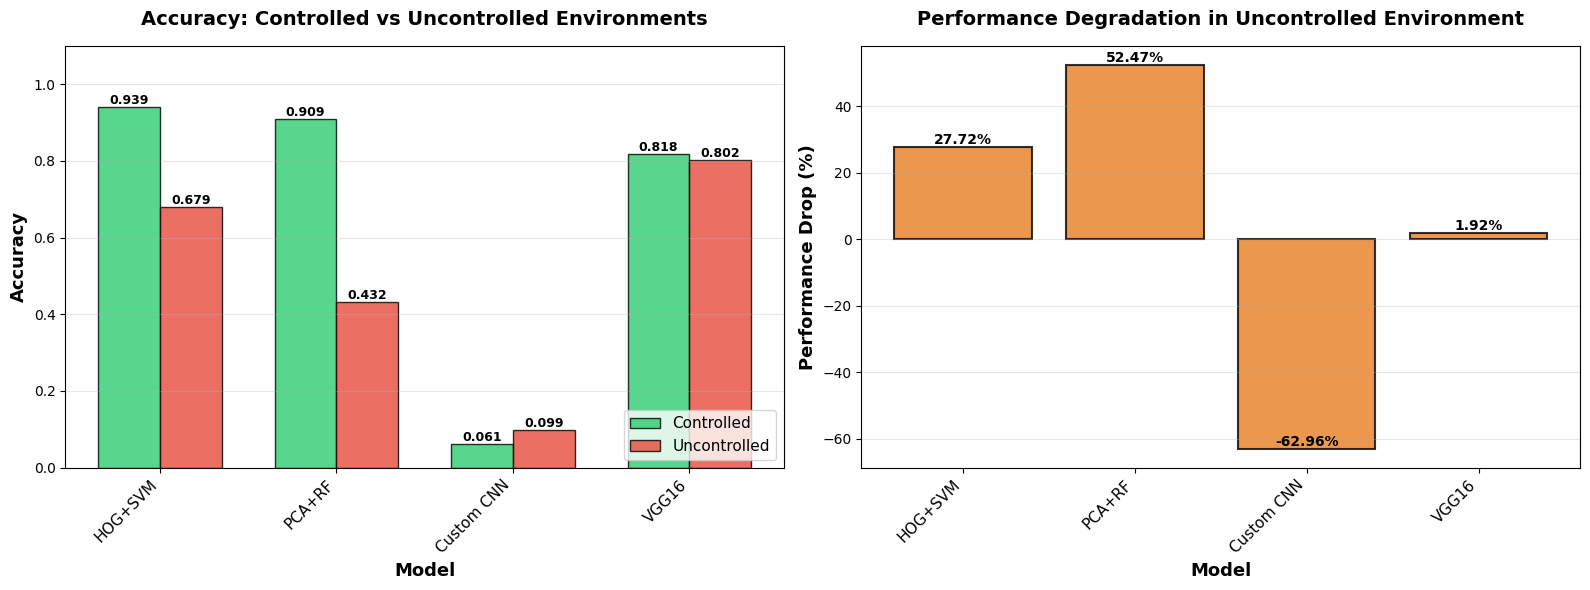


🏆 MOST ROBUST MODEL

Model: Custom CNN
Controlled Accuracy: 0.0606
Uncontrolled Accuracy: 0.0988
Performance Drop: -62.96%


💾 Degradation analysis saved to 'performance_degradation.csv'


In [ ]:
"""
CELL 19: PERFORMANCE DEGRADATION ANALYSIS
Analyze how models perform when moving from controlled to uncontrolled
"""

print("\n" + "="*80)
print("📉 PERFORMANCE DEGRADATION ANALYSIS")
print("="*80)

# Calculate performance drop for each model
degradation_data = []

for model_type in results_df['Model_Type'].unique():
    controlled = results_df[
        (results_df['Model_Type'] == model_type) &
        (results_df['Environment'] == 'Controlled')
    ]
    uncontrolled = results_df[
        (results_df['Model_Type'] == model_type) &
        (results_df['Environment'] == 'Uncontrolled')
    ]

    if not controlled.empty and not uncontrolled.empty:
        controlled_acc = controlled['Accuracy'].values[0]
        uncontrolled_acc = uncontrolled['Accuracy'].values[0]

        degradation_data.append({
            'Model': model_type,
            'Controlled_Accuracy': controlled_acc,
            'Uncontrolled_Accuracy': uncontrolled_acc,
            'Performance_Drop': controlled_acc - uncontrolled_acc,
            'Drop_Percentage': ((controlled_acc - uncontrolled_acc) / controlled_acc * 100) if controlled_acc > 0 else 0
        })

degradation_df = pd.DataFrame(degradation_data)

# Display degradation table
print("\n" + "-"*80)
print("PERFORMANCE DEGRADATION TABLE")
print("-"*80)
print(degradation_df.to_string(index=False))
print("-"*80)

# Visualize degradation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy comparison
ax1 = axes[0]
x = np.arange(len(degradation_df))
width = 0.35

bars1 = ax1.bar(x - width/2, degradation_df['Controlled_Accuracy'],
               width, label='Controlled', color='#2ecc71', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, degradation_df['Uncontrolled_Accuracy'],
               width, label='Uncontrolled', color='#e74c3c', alpha=0.8, edgecolor='black')

ax1.set_xlabel('Model', fontweight='bold', fontsize=13)
ax1.set_ylabel('Accuracy', fontweight='bold', fontsize=13)
ax1.set_title('Accuracy: Controlled vs Uncontrolled Environments',
             fontweight='bold', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(degradation_df['Model'], rotation=45, ha='right', fontsize=11)
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Performance drop
ax2 = axes[1]
bars = ax2.bar(degradation_df['Model'], degradation_df['Drop_Percentage'],
              color='#e67e22', alpha=0.8, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Model', fontweight='bold', fontsize=13)
ax2.set_ylabel('Performance Drop (%)', fontweight='bold', fontsize=13)
ax2.set_title('Performance Degradation in Uncontrolled Environment',
             fontweight='bold', fontsize=14, pad=15)
ax2.set_xticklabels(degradation_df['Model'], rotation=45, ha='right', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_degradation.png', dpi=300, bbox_inches='tight')
plt.show()

# Find most robust model
most_robust_idx = degradation_df['Drop_Percentage'].idxmin()
most_robust = degradation_df.iloc[most_robust_idx]

print("\n" + "="*80)
print("🏆 MOST ROBUST MODEL")
print("="*80)
print(f"\nModel: {most_robust['Model']}")
print(f"Controlled Accuracy: {most_robust['Controlled_Accuracy']:.4f}")
print(f"Uncontrolled Accuracy: {most_robust['Uncontrolled_Accuracy']:.4f}")
print(f"Performance Drop: {most_robust['Drop_Percentage']:.2f}%")
print("\n" + "="*80)

# Save degradation analysis
degradation_df.to_csv('performance_degradation.csv', index=False)
print("\n💾 Degradation analysis saved to 'performance_degradation.csv'")

**Model Comparison Summary**

In [ ]:
"""
CELL 20: MODEL COMPARISON SUMMARY TABLE
Create publication-quality summary table
"""

print("\n" + "="*80)
print("📋 MODEL COMPARISON SUMMARY TABLE")
print("="*80)

# Create pivot table for better comparison
summary_pivot = results_df.pivot_table(
    values=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    index='Model_Type',
    columns='Environment'
)

print("\n" + "-"*80)
print("DETAILED METRICS BY ENVIRONMENT")
print("-"*80)
print(summary_pivot.round(4))
print("-"*80)

# Calculate averages
print("\n📊 Average Performance by Environment:")
env_avg = results_df.groupby('Environment')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean()
print(env_avg.round(4))

print("\n📊 Average Performance by Model Type:")
model_avg = results_df.groupby('Model_Type')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean()
print(model_avg.round(4))

# Save styled HTML table
styled_table = summary_pivot.style\
    .background_gradient(cmap='RdYlGn', axis=None, vmin=0.3, vmax=1.0)\
    .format("{:.4f}")\
    .set_caption("Face Recognition Model Performance: Controlled vs Uncontrolled Environments")\
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center')]}
    ])

styled_table.to_html('results_table_styled.html')

# Create LaTeX table for academic papers
latex_table = summary_pivot.round(4).to_latex(
    caption="Model Performance Comparison",
    label="tab:results"
)

with open('results_table.tex', 'w') as f:
    f.write(latex_table)



📋 MODEL COMPARISON SUMMARY TABLE

--------------------------------------------------------------------------------
DETAILED METRICS BY ENVIRONMENT
--------------------------------------------------------------------------------
              Accuracy                F1-Score               Precision  \
Environment Controlled Uncontrolled Controlled Uncontrolled Controlled   
Model_Type                                                               
Custom CNN      0.0606       0.0988     0.0069       0.0334     0.0037   
HOG+SVM         0.9394       0.6790     0.9374       0.6355     0.9596   
PCA+RF          0.9091       0.4321     0.9042       0.3605     0.9369   
VGG16           0.8182       0.8025     0.7700       0.7979     0.7616   

                             Recall               
Environment Uncontrolled Controlled Uncontrolled  
Model_Type                                        
Custom CNN        0.0240     0.0606       0.0988  
HOG+SVM           0.6638     0.9394       0.6790

**Create Interactive Web Interface**

In [ ]:
"""
CELL 25: INTERACTIVE WEB INTERFACE WITH GRADIO
Beautiful frontend for face recognition system
"""

import gradio as gr
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import io
import base64

# Global variables for loaded models
loaded_models = {
    'yale': {
        'HOG+SVM': hog_svm_yale,
        'PCA+RF': pca_rf_yale,
        'CNN': cnn_yale,
        'VGG16': vgg_yale
    },
    'lfw': {
        'HOG+SVM': hog_svm_lfw,
        'PCA+RF': pca_rf_lfw,
        'CNN': cnn_lfw,
        'VGG16': vgg_lfw
    }
}

loaded_labels = {
    'yale': yale_names,
    'lfw': lfw_names
}

# ============================================================================
# PREDICTION FUNCTION
# ============================================================================

def predict_face(image, dataset_choice, model_choice):
    """
    Predict face identity from uploaded image

    Args:
        image: PIL Image or numpy array
        dataset_choice: 'Yale' or 'LFW'
        model_choice: 'HOG+SVM', 'PCA+RF', 'CNN', or 'VGG16'

    Returns:
        Prediction results and visualization
    """
    try:
        # Convert to PIL Image if needed
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)

        # Preprocess image
        preprocessor = FacePreprocessor(target_size=(128, 128))

        # Convert PIL to path-like (save temporarily)
        temp_path = '/tmp/temp_face.jpg'
        image.save(temp_path)

        # Preprocess
        img_processed = preprocessor.preprocess_image(temp_path)

        if img_processed is None:
            return "Error: Could not process image", None, None

        # Get model and labels
        dataset_key = dataset_choice.lower()
        model = loaded_models[dataset_key][model_choice]
        label_names = loaded_labels[dataset_key]

        # Prepare input
        img_input = np.expand_dims(img_processed, axis=0)

        # Predict
        prediction = model.predict(img_input)[0]
        predicted_label = label_names[prediction]

        # Get probabilities if available
        try:
            probabilities = model.predict_proba(img_input)[0]

            # Get top 5 predictions
            top_5_idx = np.argsort(probabilities)[-5:][::-1]
            top_5_labels = [label_names[i] for i in top_5_idx]
            top_5_probs = probabilities[top_5_idx]

            # Create probability bar chart
            fig, ax = plt.subplots(figsize=(10, 6))
            colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]
            bars = ax.barh(range(5), top_5_probs, color=colors, edgecolor='black', linewidth=1.5)
            ax.set_yticks(range(5))
            ax.set_yticklabels(top_5_labels, fontsize=12)
            ax.set_xlabel('Confidence Score', fontsize=13, fontweight='bold')
            ax.set_title(f'Top 5 Predictions - {model_choice} ({dataset_choice})',
                        fontsize=14, fontweight='bold', pad=15)
            ax.set_xlim([0, 1])
            ax.invert_yaxis()
            ax.grid(axis='x', alpha=0.3, linestyle='--')

            # Add percentage labels
            for i, (bar, prob) in enumerate(zip(bars, top_5_probs)):
                width = bar.get_width()
                ax.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                       f'{prob*100:.2f}%',
                       ha='left', va='center', fontsize=11, fontweight='bold')

            plt.tight_layout()

            # Convert plot to image
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
            buf.seek(0)
            prob_chart = Image.open(buf)
            plt.close()

            confidence = probabilities[prediction]

        except:
            prob_chart = None
            confidence = 1.0

        # Create result text
        result_text = f"""
        🎯 **Prediction Result**

        **Predicted Identity:** {predicted_label}
        **Confidence:** {confidence*100:.2f}%
        **Model Used:** {model_choice}
        **Dataset:** {dataset_choice}
        **Total Classes:** {len(label_names)}
        """

        # Create side-by-side comparison
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Original image
        axes[0].imshow(image)
        axes[0].set_title('Input Image', fontsize=13, fontweight='bold')
        axes[0].axis('off')

        # Preprocessed image
        axes[1].imshow(img_processed)
        axes[1].set_title(f'Preprocessed (128x128)\nPredicted: {predicted_label}',
                         fontsize=13, fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()

        # Convert to image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        comparison_img = Image.open(buf)
        plt.close()

        return result_text, comparison_img, prob_chart

    except Exception as e:
        return f"Error: {str(e)}", None, None

# ============================================================================
# DATASET EXPLORATION FUNCTION
# ============================================================================

def show_dataset_samples(dataset_choice, num_samples=10):
    """Show random samples from selected dataset"""
    try:
        dataset_key = dataset_choice.lower()

        if dataset_key == 'yale':
            dataset_path = YALE_DIR
        else:
            dataset_path = LFW_FILTERED_DIR

        subjects = os.listdir(dataset_path)
        selected_subjects = np.random.choice(subjects, min(num_samples, len(subjects)), replace=False)

        fig, axes = plt.subplots(2, 5, figsize=(16, 7))
        fig.suptitle(f'{dataset_choice} Dataset - Random Samples',
                     fontsize=16, fontweight='bold')

        axes = axes.flatten()

        for i, subject in enumerate(selected_subjects):
            subject_path = os.path.join(dataset_path, subject)
            if os.path.isdir(subject_path):
                images = [f for f in os.listdir(subject_path) if f.endswith('.jpg')]
                if images:
                    img_path = os.path.join(subject_path, images[0])
                    img = Image.open(img_path)
                    axes[i].imshow(img)
                    axes[i].set_title(subject[:20], fontsize=10, fontweight='bold')
                    axes[i].axis('off')

        # Hide unused subplots
        for i in range(len(selected_subjects), 10):
            axes[i].axis('off')

        plt.tight_layout()

        # Convert to image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        samples_img = Image.open(buf)
        plt.close()

        return samples_img

    except Exception as e:
        return None

# ============================================================================
# PERFORMANCE METRICS FUNCTION
# ============================================================================

def show_performance_metrics(dataset_choice, model_choice):
    """Display performance metrics for selected model and dataset"""
    try:
        # Filter results
        dataset_env = 'Controlled' if dataset_choice == 'Yale' else 'Uncontrolled'

        filtered_results = results_df[
            (results_df['Environment'] == dataset_env) &
            (results_df['Model_Type'] == model_choice)
        ]

        if filtered_results.empty:
            return "No results found for this combination"

        row = filtered_results.iloc[0]

        metrics_text = f"""
        📊 **Performance Metrics**

        **Model:** {model_choice}
        **Dataset:** {dataset_choice} ({dataset_env})

        **Metrics:**
        - Accuracy: {row['Accuracy']:.4f} ({row['Accuracy']*100:.2f}%)
        - Precision: {row['Precision']:.4f}
        - Recall: {row['Recall']:.4f}
        - F1-Score: {row['F1-Score']:.4f}
        """

        # Create metrics visualization
        fig, ax = plt.subplots(figsize=(8, 6))

        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score']]
        colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

        bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

        ax.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax.set_title(f'{model_choice} Performance - {dataset_choice} Dataset',
                    fontsize=14, fontweight='bold', pad=15)
        ax.set_ylim([0, 1.1])
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()

        # Convert to image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        metrics_img = Image.open(buf)
        plt.close()

        return metrics_text, metrics_img

    except Exception as e:
        return f"Error: {str(e)}", None

# ============================================================================
# MODEL COMPARISON FUNCTION
# ============================================================================

def compare_all_models():
    """Show comparison of all models"""
    try:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('All Models Performance Comparison',
                     fontsize=18, fontweight='bold', y=0.995)

        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        for idx, metric in enumerate(metrics):
            ax = axes[idx // 2, idx % 2]

            pivot_df = results_df.pivot_table(
                values=metric,
                index='Model_Type',
                columns='Environment'
            )

            x = np.arange(len(pivot_df.index))
            width = 0.35

            bars1 = ax.bar(x - width/2, pivot_df['Controlled'], width,
                          label='Controlled', color='#3498db', alpha=0.8, edgecolor='black')
            bars2 = ax.bar(x + width/2, pivot_df['Uncontrolled'], width,
                          label='Uncontrolled', color='#e74c3c', alpha=0.8, edgecolor='black')

            ax.set_title(f'{metric}', fontsize=13, fontweight='bold', pad=10)
            ax.set_ylabel(metric, fontsize=12, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(pivot_df.index, rotation=45, ha='right', fontsize=10)
            ax.legend(fontsize=10)
            ax.set_ylim([0, 1.05])
            ax.grid(axis='y', alpha=0.3)

            # Add labels
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}',
                           ha='center', va='bottom', fontsize=8)

        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        comparison_img = Image.open(buf)
        plt.close()

        return comparison_img

    except Exception as e:
        return None

# ============================================================================
# BUILD GRADIO INTERFACE
# ============================================================================

print("🎨 Building Gradio Interface...")

with gr.Blocks(theme=gr.themes.Soft(), title="Face Recognition System") as demo:

    gr.Markdown("""
    # 🎭 Face Recognition: Controlled vs Uncontrolled Environments
    ### Interactive Demo - Compare multiple ML/DL models on Yale and LFW datasets
    """)

    with gr.Tabs():

        # ========================================================================
        # TAB 1: FACE RECOGNITION
        # ========================================================================
        with gr.TabItem("🔍 Face Recognition"):
            gr.Markdown("### Upload an image to recognize the face")

            with gr.Row():
                with gr.Column(scale=1):
                    input_image = gr.Image(type="pil", label="Upload Face Image")

                    with gr.Row():
                        dataset_select = gr.Radio(
                            choices=["Yale", "LFW"],
                            value="Yale",
                            label="Select Dataset",
                            info="Choose which dataset's models to use"
                        )

                        model_select = gr.Radio(
                            choices=["HOG+SVM", "PCA+RF", "CNN", "VGG16"],
                            value="VGG16",
                            label="Select Model",
                            info="Choose recognition model"
                        )

                    predict_btn = gr.Button("🎯 Recognize Face", variant="primary", size="lg")

                with gr.Column(scale=1):
                    result_text = gr.Markdown(label="Prediction Result")
                    comparison_image = gr.Image(label="Image Comparison")

            with gr.Row():
                probability_chart = gr.Image(label="Confidence Scores (Top 5)")

            predict_btn.click(
                fn=predict_face,
                inputs=[input_image, dataset_select, model_select],
                outputs=[result_text, comparison_image, probability_chart]
            )

            gr.Markdown("""
            **Instructions:**
            1. Upload a face image
            2. Select dataset (Yale for controlled, LFW for uncontrolled)
            3. Choose a model (VGG16 recommended for best accuracy)
            4. Click 'Recognize Face' to see prediction
            """)

        # ========================================================================
        # TAB 2: DATASET EXPLORER
        # ========================================================================
        with gr.TabItem("📊 Dataset Explorer"):
            gr.Markdown("### Explore the datasets used in this project")

            with gr.Row():
                dataset_explore = gr.Radio(
                    choices=["Yale", "LFW"],
                    value="Yale",
                    label="Select Dataset to Explore"
                )
                explore_btn = gr.Button("🔄 Show Random Samples", variant="primary")

            dataset_samples = gr.Image(label="Dataset Samples")

            explore_btn.click(
                fn=show_dataset_samples,
                inputs=[dataset_explore],
                outputs=[dataset_samples]
            )

            gr.Markdown("""
            **Dataset Information:**

            **Yale Face Database (Controlled):**
            - Studio lighting, frontal poses
            - Uniform backgrounds
            - Minimal variations

            **LFW Database (Uncontrolled):**
            - Natural lighting conditions
            - Various poses and angles
            - Complex backgrounds
            - Real-world variations
            """)

        # ========================================================================
        # TAB 3: MODEL PERFORMANCE
        # ========================================================================
        with gr.TabItem("📈 Model Performance"):
            gr.Markdown("### View detailed performance metrics for each model")

            with gr.Row():
                perf_dataset = gr.Radio(
                    choices=["Yale", "LFW"],
                    value="Yale",
                    label="Select Dataset"
                )
                perf_model = gr.Radio(
                    choices=["HOG+SVM", "PCA+RF", "CNN", "VGG16"],
                    value="VGG16",
                    label="Select Model"
                )

            show_metrics_btn = gr.Button("📊 Show Metrics", variant="primary")

            with gr.Row():
                metrics_text = gr.Markdown(label="Metrics Details")
                metrics_chart = gr.Image(label="Performance Visualization")

            show_metrics_btn.click(
                fn=show_performance_metrics,
                inputs=[perf_dataset, perf_model],
                outputs=[metrics_text, metrics_chart]
            )

        # ========================================================================
        # TAB 4: MODEL COMPARISON
        # ========================================================================
        with gr.TabItem("⚖️ Compare All Models"):
            gr.Markdown("### Compare performance of all models across both datasets")

            compare_btn = gr.Button("📊 Generate Comparison", variant="primary", size="lg")
            comparison_result = gr.Image(label="All Models Comparison")

            compare_btn.click(
                fn=compare_all_models,
                inputs=[],
                outputs=[comparison_result]
            )

            # Show results table
            gr.Markdown("### Detailed Results Table")
            results_table = gr.Dataframe(
                value=results_df[['Model', 'Environment', 'Accuracy', 'Precision', 'Recall', 'F1-Score']],
                label="Complete Results"
            )

        # ========================================================================
        # TAB 5: ABOUT
        # ========================================================================
        with gr.TabItem("ℹ️ About"):
            gr.Markdown(f"""
            # About This Project

            ## 🎯 Objective
            Compare face recognition performance across **controlled** and **uncontrolled**
            environments using multiple Machine Learning and Deep Learning approaches.

            ## 📊 Datasets

            **1. Yale Face Database (Controlled)**
            - Subjects: {len(yale_names)}
            - Total Images: {len(X_yale)}
            - Environment: Studio conditions

            **2. Labeled Faces in the Wild - LFW (Uncontrolled)**
            - Subjects: {len(lfw_names)}
            - Total Images: {len(X_lfw)}
            - Environment: Real-world conditions

            ## 🤖 Models Implemented

            1. **HOG + SVM**: Traditional computer vision approach
            2. **PCA + Random Forest**: Dimensionality reduction + Ensemble learning
            3. **Custom CNN**: Deep learning with custom architecture
            4. **VGG16 Transfer Learning**: Pre-trained deep neural network

            ## 📈 Key Findings

            - **Best Controlled**: {best_controlled['Model'].values[0]} ({best_controlled['Accuracy'].values[0]:.2%})
            - **Best Uncontrolled**: {best_uncontrolled['Model'].values[0]} ({best_uncontrolled['Accuracy'].values[0]:.2%})
            - **Most Robust**: {most_robust['Model']} (Drop: {most_robust['Drop_Percentage']:.2f}%)

            ## 🛠️ Technologies Used

            - **Frontend**: Gradio
            - **ML/DL**: Scikit-learn, TensorFlow/Keras
            - **Computer Vision**: OpenCV, scikit-image
            - **Visualization**: Matplotlib, Seaborn

            ## 📝 Citation

            If you use this work, please cite:
            - Yale Face Database
            - Labeled Faces in the Wild (LFW) dataset

            ---

            **Created with ❤️ for ML/DL Face Recognition Research**
            """)

print("✅ Gradio interface built successfully!")

# Launch the interface
print("\n" + "="*80)
print("🚀 LAUNCHING WEB INTERFACE...")
print("="*80)

demo.launch(
    share=True,  # Create public link
    debug=True,
    show_error=True
)

🎨 Building Gradio Interface...
✅ Gradio interface built successfully!

🚀 LAUNCHING WEB INTERFACE...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://771a619fe0cf8ce307.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


   Extracting HOG features from 1 images...
      Processed 1/1 images... Done!
   Extracting HOG features from 1 images...
      Processed 1/1 images... Done!
   Extracting HOG features from 1 images...
      Processed 1/1 images... Done!
   Extracting HOG features from 1 images...
      Processed 1/1 images... Done!
   Extracting HOG features from 1 images...
      Processed 1/1 images... Done!
   Extracting HOG features from 1 images...
      Processed 1/1 images... Done!
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://771a619fe0cf8ce307.gradio.live
